Datei für Ferdinand: 

du musst:

- deinen Messdatendatei (\texttt(Messwerte_path)) richtig einbinden, also den entsprechenden Pfad ändern. (Bei mir waren die Dateien in Orndern entsprechend den Nummern aus der Durchführung im Skript geordnet, innerhalb dieses Messwerte_path lagen die Aufgabenordner)
- den Ausgabepfad (\texttt(Ausgabe_path)) für die Plot-figures festlegen, und unter fig.savefig den Namen der Bilder festlegen
- unter (\texttt(filepath)) einstellen, wo die TeX_results Datei unter welchem Namen (filename) gespeichert werden soll
- in der graphs Liste den Titel deiner Plots festlegen und die Achsengrößen, das findest du am besten raus, indem du einfach die Funktion peak_analysis für einen Graphen aufrufst und dann halt rumspielst mit xlim/ylim je nachdem was du sehen willst. 


Wenn du dann die vorletzte Zelle hier im Notebook ausführst, erscheint der Graph und du kannst zweimal pro Peak klicken: 
- einmal links am unteren Ende/ Fuß der Erhebung/Peakberges. 
- einmal in der Mitte, genau an den Maximumspunkt
dann wird die Peak-Linie und die FHWM gezeichnet und die Werte schonmal in einer Liste gespeichert (results)

wenn du alle Linien angeklickt hast, dann drück Stop: Jetzt wird das Bild als .png und die results in einer .txt Datei gespeichert, sodass du sie in Latex reinpasten kannst.


Meinen restlichen Code für die Aufgaben danach und davor findest du dann im anderen Dokument.


In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import scipy.constants as c
from scipy.optimize import curve_fit
from scipy.stats import chi2
from pathlib import Path
from adjustText import adjust_text
from matplotlib.widgets import Button

def figsize_cm(width_cm, height_cm):
    return (2*width_cm / 2.54, 2*height_cm / 2.54)
def comma_to_float(valstr):
    return float(valstr.replace(',','.'))

In [ ]:
base = Path.cwd()                                                   # cwd steht für current working directory
Messwerte_path = Path(base.parent.parent.parent/"Messwerte"/"234")  # also relativ zum Ort der jpynb-Datei musst du den Pfad, wo deine Messdaten liegen 
Ausgabe_path = Path(base/"Diagramme")                               # und wo du die Plot-figures gespeichert haben willst , festlegen
print(Messwerte_path)                                               # just checking if the path is right
print(Ausgabe_path)

Erst hier wird nun gezeichnet: mit index_graph kannst du auswählen, welches Natriumspektrum du zeichnen willst, dann werden der Funktion peak_analysis automatisch alle Werte übergeben, die in der Liste graphs für das geindexte Item stehen.

In [25]:
   
# ----------------------------
# Messdaten laden
# ----------------------------
graphs = [
    {                                   
        "datei": Messwerte_path/"Nr.3"/"Natriumdampflampe_kleinelinie.txt",             # Dateipfad der Messwerte des Gitterspektrometers 
        "Messreihe": "kleineLinien",                                                    # Name der Messreihe (ist nicht derselbe Name wie der der Messwerte Datei), wird später genutzt, zum Erstellen des Plot-title, der TeX_results Datei, und als Name der .png Datei des fertigen Plots 
        "xlim": (350, 550),                                                             # Wellenlängebereich der Messreihe
        "ylim": (5000, 100000),                                                         # Intensitätsbereich
    },
    {
        "datei": Messwerte_path/"Nr.3"/"Natriumdampflampe500linie.txt",
        "Messreihe": "500Linien",
        "xlim": (400, 540),
        "ylim": (1000,100000),
    },
    {
        "datei": Messwerte_path/"Nr.4"/"natrium570-615.txt",
        "Messreihe": "570-615Linien",
        "xlim": (560,625),
        "ylim": (10,1000000),    
    },
    {
        "datei": Messwerte_path/"Nr.4"/"NatriumD-Linie.txt",
        "Messreihe": "DLinien",
        "xlim": (560,625),
        "ylim": (1,1000000),
    },
    {
        "datei": Messwerte_path/"Nr.5"/"Natrium650-850.txt",
        "Messreihe": "650-850Linien",
        "xlim": (650, 860),
        "ylim": (10, 100000),
    },
]

def peak_analysis(datei_path, Messreihe, xlim=(0,1000), ylim=(0,1e6)):      # die Argumente entsprechen den Einträgen der graphs-items (Einstellungen). Übergeben werden diese Einstellungen aber erst beim aufrufen der peak_analysis Funktion
    lambda_values, intensity_values = np.loadtxt(                                   # Laden der Spalten aus der Gitterdatei in zwei Arrays, die dann zum Plotten der I(\lambda) Kurve genutzt werden.
        datei_path, 
        skiprows=17,
        converters={0:comma_to_float, 1:comma_to_float},
        comments='>',
        unpack=True
    )

    results = []                                                                    # erstellen der results-List, in der die Ergebnisse für TeX_results gespeichert werden

    # ---------------- Plot ----------------
    fig, ax = plt.subplots(figsize=(12,6))                                          # erstellen der figure (fig) und der Achsen (ax)
    plt.subplots_adjust(bottom=0.2)                                 
    ax.plot(lambda_values, intensity_values, color='blue')                          # I(\lambda) (zwei Spalten aus der Gitterdatei) werden geplottet
    ax.set_xlim(xlim)                                                               # laden des ylim-Arguments von peak_analysis
    ax.set_ylim(ylim)                                                               # ""
    ax.set_yscale('log')                    
    ax.set_xlabel("Wellenlänge [nm]")
    ax.set_ylabel("Intensität [b.E.]")
    ax.set_title(f"Natriumspektrum: {Messreihe}")                                   # Plottitel anhand des Messreihen arguments von peak_analysis wird festgelegt
    ax.grid()

    clicks = []                                                                     # erstellen der clicks Liste, in der die FHWM Klicks gespeichert werden

    ax_btn_stop = plt.axes([0.7, 0.01, 0.2, 0.05])                                      # Positionieren des Buttons relativ zu den Plot-Achsen
    btn_stop = Button(ax_btn_stop, 'Press to stop measuring', color='lightgray', hovercolor='gray')        # Erstellen des Buttons btn_stop

    # ---------------- Klick-Event ----------------                                 # Klicken zur Berechnung/Einzeichnung der FHWM
    def onclick(event):
        if event.button != 1:        # nur Linksklick
            return
        if event.inaxes != ax or event.xdata is None:                               
            return
        # Toolbar-Interaktion ignorieren (Zoom oder Pan)
        if plt.get_current_fig_manager().toolbar.mode != '':
            return
        
        clicks.append((event.xdata, event.ydata))                                   # füllen der clicks Liste mit den Positionsdaten des Mauszeigers ('click'-event.xdata)
        if len(clicks) == 2:                                                        # nach zweimal drücken (also auf dem Untergrund des Peaks und dem Peak selber) wird berechnet
            lambda_peak = clicks[1][0]                                              # clicks[1][0] nimmt aus dem ersten clicks-item (xdata, ydata) das nullte Element, beachte in der Informatik wird mit 0 angefangen
            I1, I2 = clicks[0][1], clicks[1][1]
            I_half = I1 + (I2 - I1)/2
            peak_index = np.argmin(np.abs(lambda_values - lambda_peak))             # da im Plot kontinuierliche Werte angezeigt werden, wird der nächste Datenpunkt aus der Gitterspalten Datei gesucht

            # suchen nach der linken Wellenlänge der FHWM
            i = peak_index
            while i > 0 and intensity_values[i] > I_half:                           # für 0 < lambda < lambda_peak bis zu I(lambda)=I_half läuft die Schleife 
                i -= 1
            lambda1 = lambda_values[i]                                              # lambda_1 (links) wurde gefunden

            # suchen nach der rechten Wellenlänge der FHWM
            i = peak_index
            while i < len(intensity_values)-1 and intensity_values[i] > I_half:     # für lambda > lambda_peak < maxlambdausderDatei und I(lambda) > I_half wird gesucht
                i += 1
            lambda2 = lambda_values[i]                                              # lambda_2 (rechts) wurde gefunden

            fwhm = lambda2 - lambda1                                                # berechnen der FHWM

            results.append({                                                        # eintragen der Rechenwerte in die results Liste
                'λ_peak': lambda_values[peak_index],
                'λ1': lambda1,
                'λ2': lambda2,
                'FWHM': fwhm,
                'I_half': I_half
            })

            ax.hlines(I_half, xmin=lambda1, xmax=lambda2, color="red")  # Zeichnen der FHWM
            ax.vlines(x=lambda1, ymin=I1, ymax=I_half, color="green")               
            ax.vlines(x=lambda2, ymin=I1, ymax=I_half, color="green")
            ax.vlines(x=lambda_peak, ymin=ylim[0], ymax=ylim[1], colors='gold', linewidths=0.7)

            fig.canvas.draw_idle()                                                  # keine Ahnung was das macht, irgendwie timet dies das Neuzeichnen der Grafik, wenn es die richtigen Resourcen gibt

            clicks.clear()                                                          # es wird immer nur ein Klick gespeichert, sodass man mit harten Zahlen bei I_1=clicks[0][1] arbeiten kann
    
    # ---------------- Speichern ----------------
    def save_results_to_file(filename=f"Natrium_{Messreihe}_TeXresults.txt"):       # speichern der TeX_results Datei, anhand der Messreihen-Einstellung wird der filename festgelegt
        filepath = base/"TeX_results"/ filename                                     # anhand des filenames wird der Speicherpfad festgelegt, relativ zu base (wurde am Anfang als Ort der jpynb Datei definiert)
        with open(filepath, "w") as f:                                              # results.txt wird als f geöffnet
            for res in results:                                                     # für alle Items in der results Liste 
                peak = round(res['λ_peak']/2, 1)                                      # werden die zwei in der .write benötigten Variablen benannt und mit den results Listenwerten belegt
                fwhm = round(res['FWHM'], 1)
                f.write(f"\\num{{{peak}({fwhm})}} \\\\\n")                          # für alle Einträge in der results Liste wird eine Zeile in die results.txt geschrieben

    # ---------------- STOP-Button ----------------
    def stop(event):                                                                # wenn man mit auswählen aller peaks fertig ist, stop drücken, danach wird alles gespeichert
        fig.canvas.mpl_disconnect(cid)
        btn_stop.color = 'red'
        btn_stop.hovercolor = 'red'
        btn_stop.label.set_text('Measuring done')
        fig.canvas.draw_idle()
        save_results_to_file()
        # plt.close(fig)  # optional
        fig.savefig(Ausgabe_path/f"Nr.3_{Messreihe}_FHWM.png", format="png")

    btn_stop.on_clicked(stop)                                                       # wird der Button gedrückt (also die .on_clicked-Aktion), wird die Stop Funktion ausgeführt 
    cid = fig.canvas.mpl_connect("button_press_event", onclick)                     # bei jedem Klick wird neu gezeichnet
    plt.show()


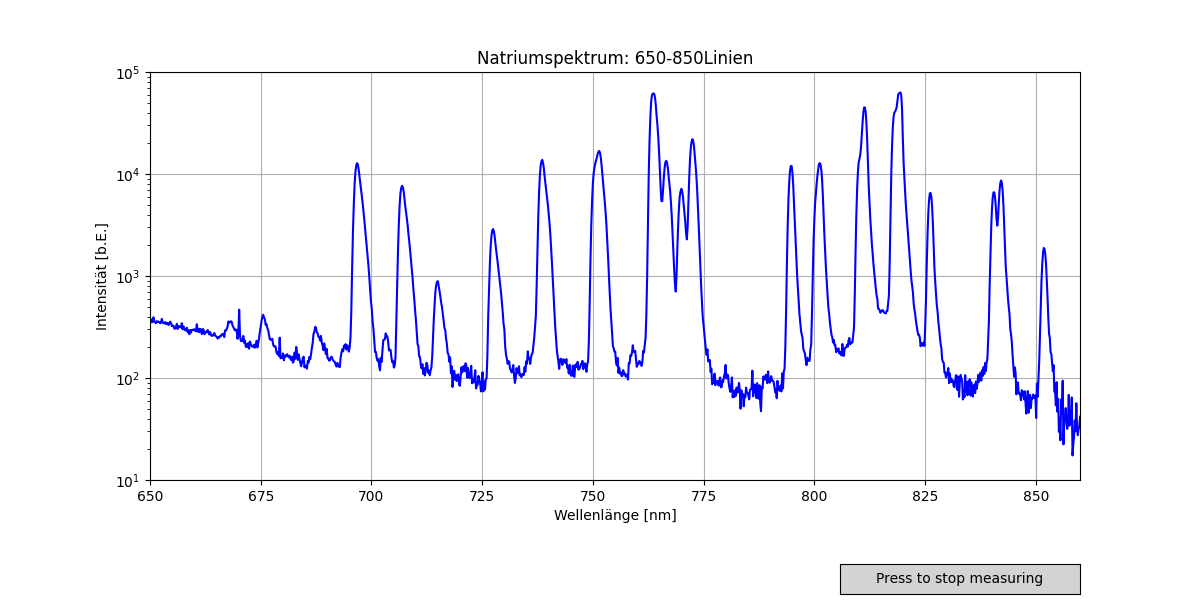

In [26]:

index_graph=4
peak_analysis(graphs[index_graph]["datei"], graphs[index_graph]["Messreihe"], graphs[index_graph]["xlim"], graphs[index_graph]["ylim"])